# TVDE Lisbon — Driver Analytics
## Notebook 03: Geographic Mobility Analysis

**Author:** Gabriel | Lisbon, Portugal | 2026

---

### Overview

This notebook analyses the geographic patterns of ride origins and destinations
across the Lisbon metropolitan area, using postal code areas (first 4 digits)
as geographic units.

### Methodology

Postal codes are grouped by their **first 4 digits** to create meaningful
geographic areas. The full 7-digit code (XXXX-XXX) produces too many unique
values for reliable pattern analysis. The 4-digit grouping corresponds to
recognisable urban zones within the Lisbon metropolitan area.

> **Interactive map:** Geographic visualisation is available in the Power BI
> dashboard (Page 4 — Geographic Concentration), which provides an interactive
> map of ride origins and destinations across the Lisbon metropolitan area.

### Data Source

| Property | Value |
|---|---|
| Input | tvde_rides_clean.csv (cleaned in notebook 01) |
| Geographic unit | Postal code area (first 4 digits of XXXX-XXX) |
| Unique origin areas | 72 |
| Unique destination areas | 86 |
| Total areas combined | 88 |

### Notebook Structure

| Group | Topic |
|---|---|
| Group 1 | Geographic concentration — top origin and destination postal codes |
| Group 2 | Mobility flows — most frequent origin → destination pairs |
| Group 3 | Earnings by postal code area — which zones generate most value |
| Group 4 | Temporal patterns — how hotspots change by time period and day type |

---
## Setup — Environment Check & Data Loading

In [1]:
# Environment check — mobility notebook

libraries = ["pandas", "matplotlib", "numpy", "folium", "branca"]

for lib in libraries:
    try:
        module = __import__(lib)
        version = getattr(module, "__version__", "unknown")
        print(f"✅ {lib} — installed (version {version})")
    except ImportError:
        print(f"❌ {lib} — NOT installed")

✅ pandas — installed (version 2.3.3)
✅ matplotlib — installed (version 3.10.8)
✅ numpy — installed (version 2.4.1)
✅ folium — installed (version 0.20.0)
✅ branca — installed (version 0.8.2)


### Load Data & Extract Postal Code Areas

Load the cleaned dataset and extract the first 4 digits of each postal code
to create geographic area groupings.

In [2]:
# MOBILITY ANALYSIS — TVDE Lisbon
# Analysing geographic patterns of ride origins and destinations

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter

# Load cleaned data
df = pd.read_csv("../data/processed/tvde_rides_clean.csv")

# Fix naming consistency
df["Platform"] = df["Platform"].str.strip().str.title()
df["Category"] = df["Category"].str.strip().str.title()

# Extract 4-digit area code from postal codes
df["Origin_Area"] = df["Origin_PostCode"].str[:4]
df["Dest_Area"] = df["Dest_PostCode"].str[:4]

print(f"Total rides: {len(df)}")
print(f"Unique origin postal codes areas: {df['Origin_Area'].nunique()}")
print(f"Unique destination postal codes areas: {df['Dest_Area'].nunique()}")
print(f"All postal codes areas combined: {pd.concat([df['Origin_Area'], df['Dest_Area']]).nunique()}")

Total rides: 2541
Unique origin postal codes areas: 72
Unique destination postal codes areas: 86
All postal codes areas combined: 88


---
## Group 1 — Geographic Concentration

**Question:** Which postal code areas generate the most ride activity?

**Method:** Count rides by origin and destination postal code area,
display top 10 for each side by side for direct comparison.

> Minimum 10 rides required for statistical relevance.

In [3]:
# GROUP 1 — Geographic concentration
# Top 10 origin and destination areas side by side

top_origins = (df["Origin_Area"]
               .value_counts()
               .head(10)
               .reset_index())
top_origins.columns = ["Origin_Area", "Origin_Rides"]

top_destinations = (df["Dest_Area"]
                    .value_counts()
                    .head(10)
                    .reset_index())
top_destinations.columns = ["Dest_Area", "Dest_Rides"]

# Side by side comparison
comparison = pd.concat([top_origins, top_destinations], axis=1)

print("TOP 10 postal codes AREAS — Origin vs Destination")
print("=" * 55)
print(f"{'Rank':<6} {'Origin':>10} {'Rides':>8}   {'Destination':>12} {'Rides':>8}")
print("-" * 55)
for i, row in comparison.iterrows():
    print(f"{i+1:<6} {row['Origin_Area']:>10} {row['Origin_Rides']:>8}   "
          f"{row['Dest_Area']:>12} {row['Dest_Rides']:>8}")
print("=" * 55)

TOP 10 postal codes AREAS — Origin vs Destination
Rank       Origin    Rides    Destination    Rides
-------------------------------------------------------
1            1300      278           1300      290
2            1500      255           1500      276
3            1600      172           1700      200
4            1400      161           1600      152
5            1700      154           1495      136
6            1495      128           1400      126
7            1990      107           2625      109
8            2790      103           2790      108
9            1070       94           1990       87
10           2625       93           1070       82


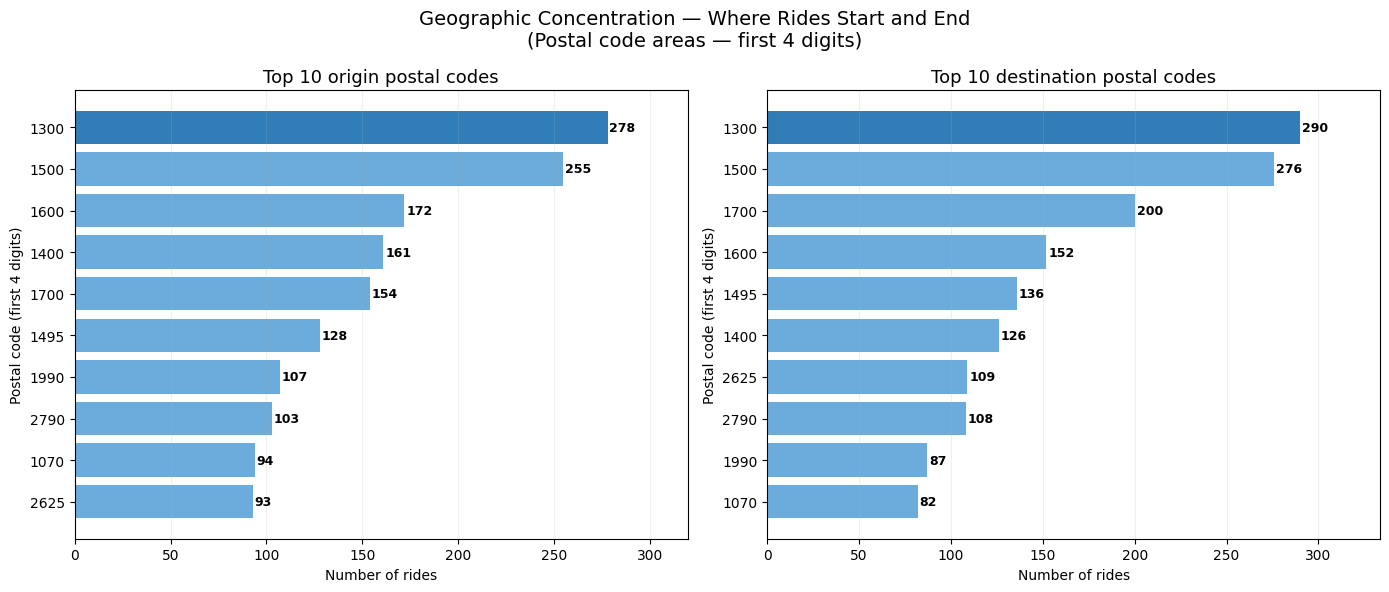

In [4]:
# GROUP 1 — Visual: Top 10 Origin vs Destination postal codes

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Top 10 Origin postal codes
colors_origin = ["#1a6faf" if i == 0 else "#5ba3d9"
                 for i in range(len(top_origins))]

bars1 = ax1.barh(top_origins["Origin_Area"].astype(str)[::-1],
                 top_origins["Origin_Rides"][::-1],
                 color=colors_origin[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars1, top_origins["Origin_Rides"][::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", fontsize=9, fontweight="bold")

ax1.set_title("Top 10 origin postal codes", fontsize=13)
ax1.set_xlabel("Number of rides", fontsize=10)
ax1.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax1.set_xlim(0, top_origins["Origin_Rides"].max() * 1.15)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — Top 10 Destination postal codes
colors_dest = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(top_destinations))]

bars2 = ax2.barh(top_destinations["Dest_Area"].astype(str)[::-1],
                 top_destinations["Dest_Rides"][::-1],
                 color=colors_dest[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars2, top_destinations["Dest_Rides"][::-1]):
    ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f"{val}", va="center", fontsize=9, fontweight="bold")

ax2.set_title("Top 10 destination postal codes", fontsize=13)
ax2.set_xlabel("Number of rides", fontsize=10)
ax2.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax2.set_xlim(0, top_destinations["Dest_Rides"].max() * 1.15)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Geographic Concentration — Where Rides Start and End\n"
             "(Postal code areas — first 4 digits)",
             fontsize=14)
plt.tight_layout()
plt.savefig("../images/mobility_top10_postal_codes.png", dpi=150,
            bbox_inches="tight")
plt.show()


## Group 1 — Geographic Concentration

**Top 10 origin and destination postal code areas:**

| Rank | Origin PC | Rides | Destination PC | Rides |
|---|---|---|---|---|
| 1 | 1300 | 278 | 1300 | 290 |
| 2 | 1500 | 255 | 1500 | 276 |
| 3 | 1600 | 172 | 1700 | 200 |
| 4 | 1400 | 161 | 1600 | 152 |
| 5 | 1700 | 154 | 1495 | 136 |
| 6 | 1495 | 128 | 1400 | 126 |
| 7 | 1990 | 107 | 2625 | 109 |
| 8 | 2790 | 103 | 2790 | 108 |
| 9 | 1070 | 94 | 1990 | 87 |
| 10 | 2625 | 93 | 1070 | 82 |

**Interpretation:**
Postal codes 1300 and 1500 dominate both origins and destinations —
these central Lisbon zones are the core of TVDE mobility demand.
The top 6 origin areas match the top 6 destination areas (in a slightly
different order), confirming that high-demand zones attract both
outgoing and incoming rides.

**Key insight:**
Postal code 1700 ranks 5th in origins but 3rd in destinations —
more people arrive in this zone than depart, suggesting it is a
net destination zone (commercial or work-related activity).
Areas 1990 and 1070 are more prominent as origins than destinations —
typical of residential peripheral zones where people depart for
central areas.

---
## Group 2 — Mobility Flows

**Question:** What are the most frequent origin → destination pairs?
Are rides mostly within the same area or between different areas?

**Method:** Create flow pairs (Origin_Area → Dest_Area), count frequency,
flag same-area rides, and visualise the top 15 flows.

In [5]:
# GROUP 2 — Mobility flows
# Most frequent origin → destination postal code pairs

# Create flow pairs
df["Flow"] = df["Origin_Area"] + " → " + df["Dest_Area"]

# Top 15 flows
top_flows = (df["Flow"]
             .value_counts()
             .head(15)
             .reset_index())
top_flows.columns = ["Flow", "Rides"]
top_flows["Origin_PostCode"] = top_flows["Flow"].str.split(" → ").str[0]
top_flows["Dest_PostCode"] = top_flows["Flow"].str.split(" → ").str[1]
top_flows["Is_Same_Area"] = (top_flows["Origin_PostCode"] ==
                              top_flows["Dest_PostCode"])

print("TOP 15 MOST FREQUENT MOBILITY FLOWS")
print("(Postal code areas — first 4 digits)")
print("=" * 60)
print(f"{'Rank':<6} {'Origin PC':<12} {'Dest PC':<12} "
      f"{'Rides':>8} {'Same Area':>12}")
print("-" * 60)
for i, row in top_flows.iterrows():
    same = "Yes" if row["Is_Same_Area"] else "No"
    print(f"{i+1:<6} {row['Origin_PostCode']:<12} "
          f"{row['Dest_PostCode']:<12} "
          f"{row['Rides']:>8} {same:>12}")
print("=" * 60)

same_area = df[df["Origin_Area"] == df["Dest_Area"]]
print(f"\nRides within same postal code area: {len(same_area)} "
      f"({len(same_area)/len(df)*100:.1f}%)")
print(f"Rides between different areas:      {len(df)-len(same_area)} "
      f"({(len(df)-len(same_area))/len(df)*100:.1f}%)")

TOP 15 MOST FREQUENT MOBILITY FLOWS
(Postal code areas — first 4 digits)
Rank   Origin PC    Dest PC         Rides    Same Area
------------------------------------------------------------
1      1500         1300               44           No
2      1300         1300               39          Yes
3      1300         1500               34           No
4      1300         1700               28           No
5      1600         1500               28           No
6      1500         1700               27           No
7      1070         1300               25           No
8      1300         1400               25           No
9      1400         1500               25           No
10     1400         1300               24           No
11     1600         1300               23           No
12     2615         2625               23           No
13     1500         1495               22           No
14     1990         2625               22           No
15     1500         1600               19

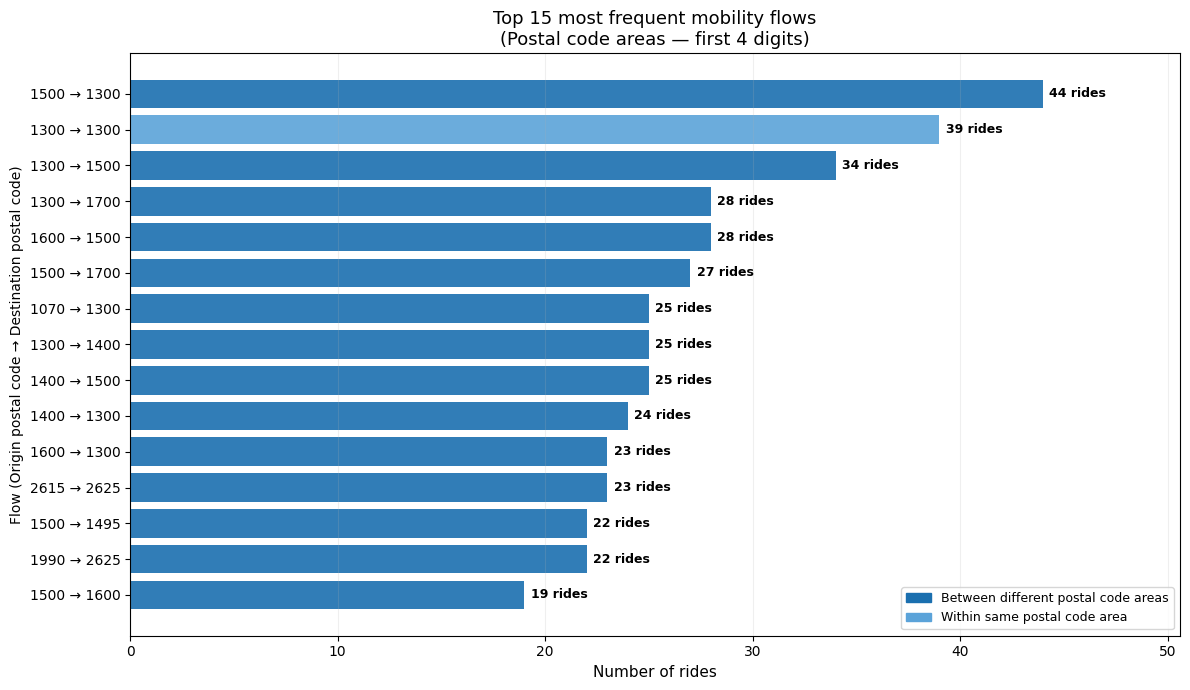

In [6]:
# GROUP 2 — Visual: Top 15 mobility flows

fig, ax = plt.subplots(figsize=(12, 7))

colors_flow = ["#1a6faf" if not same else "#5ba3d9"
               for same in top_flows["Is_Same_Area"]]

bars = ax.barh(top_flows["Flow"][::-1],
               top_flows["Rides"][::-1],
               color=colors_flow[::-1], alpha=0.9, edgecolor="none")

for bar, val in zip(bars, top_flows["Rides"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val} rides", va="center", fontsize=9, fontweight="bold")

# Legend
same_patch = mpatches.Patch(color="#5ba3d9", label="Within same postal code area")
diff_patch = mpatches.Patch(color="#1a6faf", label="Between different postal code areas")
ax.legend(handles=[diff_patch, same_patch], fontsize=9, loc="lower right")

ax.set_title("Top 15 most frequent mobility flows\n"
             "(Postal code areas — first 4 digits)",
             fontsize=13)
ax.set_xlabel("Number of rides", fontsize=11)
ax.set_ylabel("Flow (Origin postal code → Destination postal code)", fontsize=10)
ax.set_xlim(0, top_flows["Rides"].max() * 1.15)
ax.grid(True, alpha=0.2, axis="x")

plt.tight_layout()
plt.savefig("../images/mobility_top15_flows.png", dpi=150,
            bbox_inches="tight")
plt.show()


## Group 2 — Mobility Flows

**Top 15 most frequent origin → destination flows:**

| Rank | Flow | Rides | Same Area |
|---|---|---|---|
| 1 | 1500 → 1300 | 44 | No |
| 2 | 1300 → 1300 | 39 | Yes |
| 3 | 1300 → 1500 | 34 | No |
| 4 | 1300 → 1700 | 28 | No |
| 5 | 1600 → 1500 | 28 | No |
| 6 | 1500 → 1700 | 27 | No |
| 7 | 1070 → 1300 | 25 | No |
| 8 | 1300 → 1400 | 25 | No |
| 9 | 1400 → 1500 | 25 | No |
| 10 | 1400 → 1300 | 24 | No |

**Rides within same postal code area:** 138 (5.4%)
**Rides between different areas:** 2,403 (94.6%)

**Interpretation:**
94.6% of all rides connect different postal code areas, confirming
that TVDE in Lisbon is primarily an inter-neighbourhood mobility
service, not a local short-trip service.

**Key insight:**
The 1300 ↔ 1500 corridor is the most active in both directions,
though asymmetric — 1500 → 1300 leads with 44 rides, while
1300 → 1500 follows with 34. Postal codes 1300, 1500 and 1700 form
the core mobility triangle of Lisbon — they appear as both origin
and destination in the majority of top flows.

The flow 1990 → 2625 is the only top-15 flow connecting the
northern periphery (Sacavém) to the western coast (Cascais area),
suggesting occasional but consistent demand on this corridor.

---
## Group 3 — Earnings by Postal Code Area

**Question:** Which postal code areas generate the highest average earnings per ride?
Is there a trade-off between volume and value?

**Method:** Group rides by origin and destination area, calculate average and total
earnings per area. Only areas with at least 10 rides are included to ensure
statistical relevance.

In [7]:
# GROUP 3 — Earnings by postal code area
# Which origin postal codes generate the most value per ride?

origin_earnings = df.groupby("Origin_Area").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    avg_eur_per_km=("Distance_Km", lambda x:
                    (df.loc[x.index, "Driver_Earnings_EUR"] / x).mean()),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

origin_earnings = origin_earnings[
    origin_earnings["total_rides"] >= 10
].sort_values("avg_earnings", ascending=False).reset_index(drop=True)

origin_earnings.index += 1
origin_earnings.columns = ["Postal Code", "Rides",
                            "Avg Earnings (€)", "Avg €/km",
                            "Total Earnings (€)"]
origin_earnings["Avg Earnings (€)"] = origin_earnings["Avg Earnings (€)"].round(2)
origin_earnings["Avg €/km"] = origin_earnings["Avg €/km"].round(2)
origin_earnings["Total Earnings (€)"] = origin_earnings["Total Earnings (€)"].round(2)

# Reorder columns — Avg Earnings first for clarity
origin_earnings = origin_earnings[["Postal Code", "Avg Earnings (€)",
                                    "Avg €/km", "Rides",
                                    "Total Earnings (€)"]]

dest_earnings = df.groupby("Dest_Area").agg(
    total_rides=("Ride_ID", "count"),
    avg_earnings=("Driver_Earnings_EUR", "mean"),
    total_earnings=("Driver_Earnings_EUR", "sum")
).reset_index()

dest_earnings = dest_earnings[
    dest_earnings["total_rides"] >= 10
].sort_values("avg_earnings", ascending=False).reset_index(drop=True)

dest_earnings.index += 1
dest_earnings.columns = ["Postal Code", "Rides",
                          "Avg Earnings (€)", "Total Earnings (€)"]
dest_earnings["Avg Earnings (€)"] = dest_earnings["Avg Earnings (€)"].round(2)
dest_earnings["Total Earnings (€)"] = dest_earnings["Total Earnings (€)"].round(2)

# Reorder columns — Avg Earnings first for clarity
dest_earnings = dest_earnings[["Postal Code", "Avg Earnings (€)",
                                "Rides", "Total Earnings (€)"]]

print("TOP 10 ORIGIN POSTAL CODES BY AVG EARNINGS PER RIDE")
print("(Minimum 10 rides for statistical relevance)")
display(origin_earnings.head(10))

print("\nTOP 10 DESTINATION POSTAL CODES BY AVG EARNINGS PER RIDE")
print("(Minimum 10 rides for statistical relevance)")
display(dest_earnings.head(10))

TOP 10 ORIGIN POSTAL CODES BY AVG EARNINGS PER RIDE
(Minimum 10 rides for statistical relevance)


,Postal Code,Avg Earnings (€),Avg €/km,Rides,Total Earnings (€)
1,2785,8.56,0.58,12,102.67
2,2625,8.40,0.75,93,780.88
3,2760,8.25,1.19,10,82.49
4,2690,7.76,0.68,15,116.46
5,2615,7.53,0.68,78,587.18
6,2775,7.46,0.69,19,141.69
7,1100,7.45,0.99,27,201.27
8,2745,7.19,0.66,20,143.85
9,2780,7.09,0.84,30,212.67
10,1800,7.03,0.61,70,492.27



TOP 10 DESTINATION POSTAL CODES BY AVG EARNINGS PER RIDE
(Minimum 10 rides for statistical relevance)


,Postal Code,Avg Earnings (€),Rides,Total Earnings (€)
1,1100,8.54,13,111.08
2,2675,8.38,16,134.01
3,1200,8.28,53,438.66
4,2775,8.22,26,213.73
5,2615,8.12,27,219.11
6,1150,7.93,14,111.02
7,1900,7.74,19,147.02
8,2780,7.68,31,237.97
9,2745,7.52,18,135.43
10,1449,7.01,11,77.06


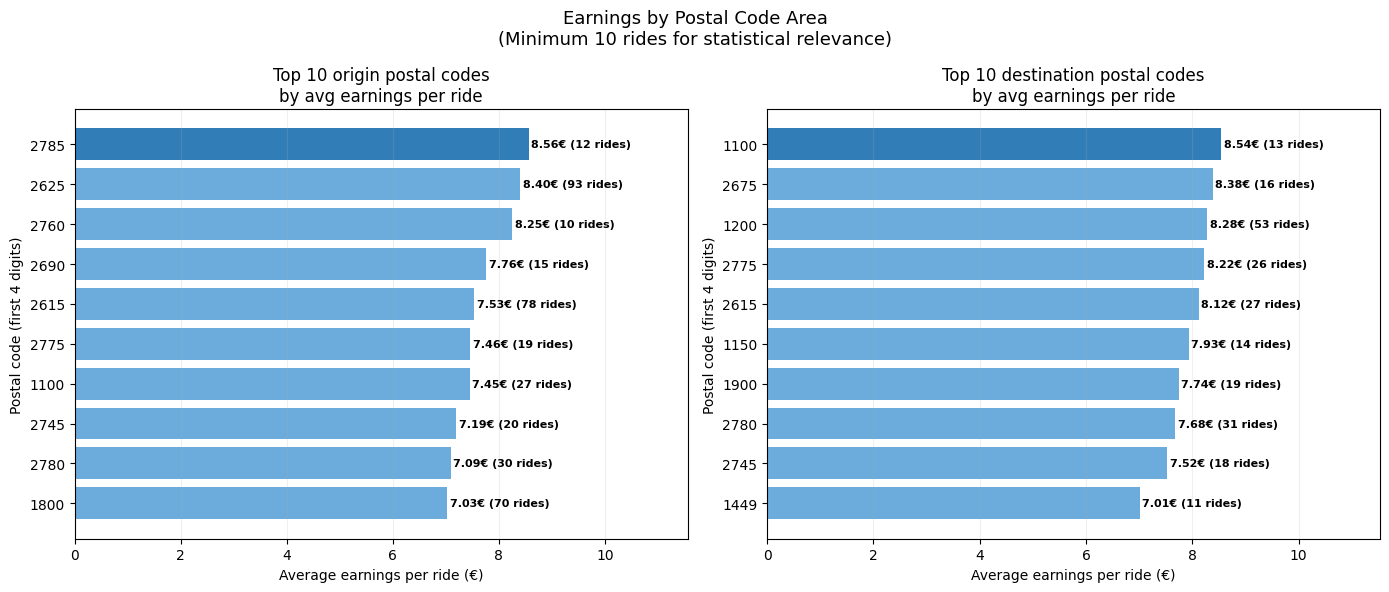

In [8]:
# GROUP 3 — Visual: Avg earnings by postal code area

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Chart 1 — Origin postal codes
origin_plot = origin_earnings.head(10).reset_index()
colors_orig = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(origin_plot))]

bars1 = ax1.barh(origin_plot["Postal Code"].astype(str)[::-1],
                 origin_plot["Avg Earnings (€)"][::-1],
                 color=colors_orig[::-1], alpha=0.9, edgecolor="none")

for bar, val, rides in zip(bars1,
                            origin_plot["Avg Earnings (€)"][::-1],
                            origin_plot["Rides"][::-1]):
    ax1.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"{val:.2f}€ ({rides} rides)",
             va="center", fontsize=8, fontweight="bold")

ax1.set_title("Top 10 origin postal codes\nby avg earnings per ride",
              fontsize=12)
ax1.set_xlabel("Average earnings per ride (€)", fontsize=10)
ax1.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax1.set_xlim(0, origin_plot["Avg Earnings (€)"].max() * 1.35)
ax1.grid(True, alpha=0.2, axis="x")

# Chart 2 — Destination postal codes
dest_plot = dest_earnings.head(10).reset_index()
colors_dest = ["#1a6faf" if i == 0 else "#5ba3d9"
               for i in range(len(dest_plot))]

bars2 = ax2.barh(dest_plot["Postal Code"].astype(str)[::-1],
                 dest_plot["Avg Earnings (€)"][::-1],
                 color=colors_dest[::-1], alpha=0.9, edgecolor="none")

for bar, val, rides in zip(bars2,
                            dest_plot["Avg Earnings (€)"][::-1],
                            dest_plot["Rides"][::-1]):
    ax2.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f"{val:.2f}€ ({rides} rides)",
             va="center", fontsize=8, fontweight="bold")

ax2.set_title("Top 10 destination postal codes\nby avg earnings per ride",
              fontsize=12)
ax2.set_xlabel("Average earnings per ride (€)", fontsize=10)
ax2.set_ylabel("Postal code (first 4 digits)", fontsize=10)
ax2.set_xlim(0, dest_plot["Avg Earnings (€)"].max() * 1.35)
ax2.grid(True, alpha=0.2, axis="x")

plt.suptitle("Earnings by Postal Code Area\n"
             "(Minimum 10 rides for statistical relevance)",
             fontsize=13)
plt.tight_layout()
plt.savefig("../images/mobility_earnings_by_postal_code.png",
            dpi=150, bbox_inches="tight")
plt.show()


## Group 3 — Earnings by Postal Code Area

**Top 5 origin postal codes by average earnings per ride:**

| Rank | Postal Code | Avg Earnings | Avg €/km | Rides |
|---|---|---|---|---|
| 1 | 2785 | 8.56 € | 0.58 €/km | 12 |
| 2 | 2625 | 8.40 € | 0.75 €/km | 93 |
| 3 | 2760 | 8.25 € | 1.19 €/km | 10 |
| 4 | 2690 | 7.76 € | 0.68 €/km | 15 |
| 5 | 2615 | 7.53 € | 0.68 €/km | 78 |

**Top 5 destination postal codes by average earnings per ride:**

| Rank | Postal Code | Avg Earnings | Rides |
|---|---|---|---|
| 1 | 1100 | 8.54 € | 13 |
| 2 | 2675 | 8.38 € | 16 |
| 3 | 1200 | 8.28 € | 53 |
| 4 | 2775 | 8.22 € | 26 |
| 5 | 2615 | 8.12 € | 27 |

**Interpretation:**
The highest-earning postal codes are predominantly in the 2xxx range
(Lisbon metropolitan periphery), reflecting longer rides that generate
higher absolute earnings. The most frequent zones (1300, 1500, 1700)
do not appear in the top earners list — high volume does not equal
high average value per ride.

**Key insight:**
There is a general trade-off between volume and value per ride, with
one notable exception: 2625 combines high volume (93 rides) with
above-average earnings (8.40 €/ride), making it both a high-traffic
and high-value origin zone. Central zones (1300, 1500) generate
consistent volume at moderate earnings per ride (~6–7€), while most
peripheral zones (2785, 2760, 2690) generate fewer but higher-value
rides (~7.5–8.6€). A balanced strategy combines central zone
availability for volume with selective acceptance of peripheral
rides for value.

---
## Group 4 — Temporal Patterns by Postal Code Area

**Question:** Do geographic hotspots change across different time periods and day types?
Is the pattern consistent throughout the working day?

**Method:** Filter to working hours (13:00–22:00), group into three time periods
(Afternoon, Peak, Evening) and compare top 5 origin areas across periods and day types.

> Morning rides (before 13:00) represent less than 5% of total rides and are
> excluded to reflect the driver's regular working schedule and avoid distorting patterns.

In [9]:

def time_period(hour):
    if hour < 17:
        return "Afternoon (13:00-17:00)"
    elif hour < 20:
        return "Peak (17:00-20:00)"
    else:
        return "Evening (after 20:00)"

df["Hour"] = pd.to_datetime(df["Start_Time"].astype(str),
                             format="%H:%M:%S").dt.hour
df["Day_Type"] = pd.to_datetime(df["Date"]).dt.dayofweek.apply(
    lambda x: "Weekend" if x >= 5 else "Weekday"
)

# Filter to working hours only
df_working = df[df["Hour"] >= 13].copy()
df_working["Time_Period"] = df_working["Hour"].apply(time_period)

periods = ["Afternoon (13:00-17:00)",
           "Peak (17:00-20:00)",
           "Evening (after 20:00)"]

# Build summary table — top 5 per period
rows = []
for rank in range(5):
    row = {"Rank": rank + 1}
    for period in periods:
        subset = df_working[df_working["Time_Period"] == period]
        top5 = (subset["Origin_Area"]
                .value_counts()
                .head(5)
                .reset_index())
        top5.columns = ["Postal Code", "Rides"]
        if rank < len(top5):
            row[period] = (f"{top5.iloc[rank]['Postal Code']} "
                           f"({top5.iloc[rank]['Rides']})")
        else:
            row[period] = "-"
    rows.append(row)

df_periods = pd.DataFrame(rows).set_index("Rank")

# Build weekday vs weekend table
rows_day = []
for rank in range(5):
    row = {"Rank": rank + 1}
    for day_type in ["Weekday", "Weekend"]:
        subset = df_working[df_working["Day_Type"] == day_type]
        top5 = (subset["Origin_Area"]
                .value_counts()
                .head(5)
                .reset_index())
        top5.columns = ["Postal Code", "Rides"]
        if rank < len(top5):
            row[day_type] = (f"{top5.iloc[rank]['Postal Code']} "
                             f"({top5.iloc[rank]['Rides']})")
        else:
            row[day_type] = "-"
    rows_day.append(row)

df_days = pd.DataFrame(rows_day).set_index("Rank")

print(f"Working hours rides analysed: {len(df_working)} "
      f"({len(df_working)/len(df)*100:.1f}% of total)")
print("\nTOP 5 ORIGIN POSTAL CODES BY TIME PERIOD")
print("(Format: Postal Code (rides) | Working hours only)")
display(df_periods)

print("\nTOP 5 ORIGIN POSTAL CODES — WEEKDAY vs WEEKEND")
print("(Format: Postal Code (rides) | Working hours only)")
display(df_days)

Working hours rides analysed: 2461 (96.9% of total)

TOP 5 ORIGIN POSTAL CODES BY TIME PERIOD
(Format: Postal Code (rides) | Working hours only)


,Afternoon (13:00-17:00),Peak (17:00-20:00),Evening (after 20:00)
Rank,,,
1,1300 (130),1300 (124),1990 (45)
2,1500 (123),1500 (104),1700 (31)
3,1600 (80),1400 (74),1800 (28)
4,1700 (80),1600 (66),1500 (26)
5,1400 (75),1495 (56),1600 (24)



TOP 5 ORIGIN POSTAL CODES — WEEKDAY vs WEEKEND
(Format: Postal Code (rides) | Working hours only)


,Weekday,Weekend
Rank,,
1,1300 (181),1300 (90)
2,1500 (179),1500 (74)
3,1600 (123),1700 (55)
4,1400 (113),1400 (47)
5,1495 (103),1600 (47)


## Group 4 — Temporal Patterns by Postal Code Area

**Analysis restricted to working hours (13:00–22:00)**
Morning rides (before 13:00) represent 3.1% of total rides and are
excluded to reflect the driver's regular working schedule and avoid
distorting geographic patterns.

**Top 5 origin postal codes by time period:**

| Rank | Afternoon (13-17h) | Peak (17-20h) | Evening (after 20h) |
|---|---|---|---|
| 1 | 1300 (130) | 1300 (124) | 1990 (45) |
| 2 | 1500 (123) | 1500 (104) | 1700 (31) |
| 3 | 1600 (80) | 1400 (74) | 1800 (28) |
| 4 | 1700 (80) | 1600 (66) | 1500 (26) |
| 5 | 1400 (75) | 1495 (56) | 1600 (24) |

**Weekday vs Weekend:**

| Rank | Weekday | Weekend |
|---|---|---|
| 1 | 1300 (181) | 1300 (90) |
| 2 | 1500 (179) | 1500 (74) |
| 3 | 1600 (123) | 1700 (55) |
| 4 | 1400 (113) | 1400 (47) |
| 5 | 1495 (103) | 1600 (47) |

**Interpretation:**
The geographic hotspot pattern is remarkably stable across time
periods and day types. Postal codes 1300 and 1500 consistently
lead in both afternoon and peak hours, on both weekdays and weekends.

**Key insight:**
The most notable shift occurs in the evening (after 20:00), where
postal code 1990 (Sacavém/northern periphery) rises to 1st place —
a zone that rarely features in other periods. This suggests increased
residential demand from peripheral areas in the late evening as
people return home. The weekday vs weekend pattern is nearly
identical, confirming that geographic demand in Lisbon is driven
by residential and urban structure rather than work schedules alone.

**Practical conclusion:**
Positioning in the 1300–1500 corridor during afternoon and peak hours
maximises ride volume. After 20:00, shifting attention to the 1990
and 1700 zones captures the evening residential demand pattern.

---
## Mobility Analysis — Key Conclusions

*(Values will be updated when the full August 2026 dataset is available)*

## Mobility Analysis — Key Conclusions

| Finding | Value |
|---|---|
| Total areas analysed | 88 unique postal code areas |
| Top origin area | 1300 (278 rides, 10.9% of total) |
| Top destination area | 1300 (290 rides, 11.4% of total) |
| Most frequent flow | 1500 → 1300 (44 rides) |
| Inter-area rides | 94.6% of all rides |
| Highest-earning origin | 2785 (avg 8.56 €/ride) |
| Highest-earning destination | 1100 (avg 8.54 €/ride) |
| Most stable hotspot | 1300 — leads in all time periods and day types |
| Evening shift | 1990 rises to 1st place after 20:00 |

**Overall conclusion:**
TVDE mobility in the Lisbon area is concentrated in a core triangle
of postal codes (1300, 1500, 1700) that consistently generate the
highest ride volume across all time periods and day types. Peripheral
zones generally offer higher earnings per ride but lower volume, with
2625 standing out as a zone combining both strong volume and
above-average earnings. The optimal driver strategy combines central
zone positioning for consistent volume with selective acceptance of
higher-value rides from peripheral origins.

**Note:** Geographic visualisation is available in the Power BI
dashboard (Page 4 — Geographic Concentration), which provides an
interactive map of ride origins and destinations across the
Lisbon metropolitan area.